In [54]:
import pandas as pd 

# Load the features (X) and the target (y)
X = pd.read_csv('../data/processed/X_features.csv')
y = pd.read_csv('../data/processed/y_target.csv')

# Print shape 
print("X (Features) shape:", X.shape)
print("y (Target) shape:", y.shape)

# First 5 rows 
print("y type:", type(y))
print("X type:", type(X))
pd.set_option('display.max_columns', None)

X.head()


X (Features) shape: (3630, 30)
y (Target) shape: (3630, 1)
y type: <class 'pandas.DataFrame'>
X type: <class 'pandas.DataFrame'>


,Marital status,Nacionality,Gender,Age at enrollment,Displaced,International,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Educational special needs,Debtor,Tuition fees up to date,Scholarship holder,Unemployment rate,Inflation rate,GDP,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Admission grade,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations)
0,1,1,1,20,1,0,19,12,5,9,0,0,1,0,10.8,1.4,1.74,17,5,171,1,1,122.0,127.3,0,0,0,0,0.000000,0
1,1,1,1,19,1,0,1,3,3,3,0,0,0,0,13.9,-0.3,0.79,15,1,9254,1,1,160.0,142.5,0,6,6,6,14.000000,0
2,1,1,1,19,1,0,37,37,9,9,0,0,0,0,10.8,1.4,1.74,1,5,9070,1,1,122.0,124.8,0,6,0,0,0.000000,0
3,1,1,0,20,1,0,38,37,5,3,0,0,1,0,9.4,-0.8,-3.12,17,2,9773,1,1,122.0,119.6,0,6,8,6,13.428571,0
4,2,1,0,45,0,0,37,38,9,9,0,0,1,0,13.9,-0.3,0.79,39,1,8014,0,1,100.0,141.5,0,6,9,5,12.333333,0


In [55]:
# Squeeze y into 1D array 
y = y.squeeze()

print("y type:", type(y))
print("y shape:", y.shape)
print("y values:", y.value_counts())

y type: <class 'pandas.Series'>
y shape: (3630,)
y values: Target
0    2209
1    1421
Name: count, dtype: int64


VIF Analysis

In [39]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Define the subset of numerical features
numerical_cols = [
    'Age at enrollment', 
    'Previous qualification (grade)', 
    'Admission grade',
    'Unemployment rate', 
    'Inflation rate', 
    'GDP', 
    'Application order',
    'Curricular units 1st sem (credited)', 
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)', 
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)', 
    'Curricular units 1st sem (without evaluations)'
]
# Isolate numerical features to prevent dtypes error during calculations 
X_numerical = X[numerical_cols]

# Add the constant 
X_numerical_with_constant = add_constant(X_numerical)

# Calculate VIF for each, we create a new empty table to store the results 
vif_data = pd.DataFrame()

# Create the first column and fill it with feature names 
vif_data["Feature"] = X_numerical_with_constant.columns

# Calculate VIF for each feature to detect multicollinearity
vif_scores = []

for i in range(len(X_numerical_with_constant.columns)):
    score = variance_inflation_factor(X_numerical_with_constant.values, i)

    vif_scores.append(score)
vif_data["VIF"] = vif_scores

# Sort results and drop the 'const' row since it's just our dummy variable
vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)
vif_data = vif_data[vif_data["Feature"] != "const"]

vif_data

,Feature,VIF
1,Curricular units 1st sem (approved),7.127741
2,Curricular units 1st sem (enrolled),5.008860
3,Curricular units 1st sem (credited),3.954324
4,Curricular units 1st sem (grade),3.763041
5,Curricular units 1st sem (evaluations),2.550314
6,Admission grade,1.571499
7,Previous qualification (grade),1.544095
8,Age at enrollment,1.271910
9,GDP,1.207861
10,Unemployment rate,1.171838


In [ ]:
# Define the subset of numerical features
numerical_cols = [
    'Age at enrollment', 
    'Previous qualification (grade)', 
    'Admission grade',
    'Unemployment rate', 
    'Inflation rate', 
    'GDP', 
    'Application order',
    'Curricular units 1st sem (credited)', 
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)', 
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)', 
    'Curricular units 1st sem (without evaluations)'
]

# Define the exact column to look at 
target_col = 'Target'
columns_to_keep = numerical_cols + [target_col]

# Group the data, calculate Mean and Std and round it to 2 decimal places 
decs_stats = df[columns_to_keep].groupby(target_col).agg(['mean', 'std']).round(2)

# Transpose the table so features are on the left and status on top
decs_stats = decs_stats.T

decs_stats


Target                                               Dropout  Enrolled  \
Age at enrollment                              mean    26.07     22.37   
                                               std      8.70      6.30   
Previous qualification (grade)                 mean   131.11    131.21   
                                               std     12.87     12.87   
Admission grade                                mean   124.96    125.53   
                                               std     15.13     13.79   
Unemployment rate                              mean    11.62     11.27   
                                               std      2.77      2.63   
Inflation rate                                 mean     1.28      1.21   
                                               std      1.40      1.37   
GDP                                            mean    -0.15      0.05   
                                               std      2.25      2.32   
Application order                              mean     1.59      1.63   
                                               std      1.22      1.21   
Curricular units 1st sem (credited)            mean     0.61      0.51   
                                               std      2.10      1.72   
Curricular units 1st sem (enrolled)            mean     5.82      5.96   
                                               std      2.33      1.99   
Curricular units 1st sem (evaluations)         mean     7.75      9.34   
                                               std      4.92      3.46   
Curricular units 1st sem (approved)            mean     2.55      4.32   
                                               std      2.86      2.29   
Curricular units 1st sem (grade)               mean     7.26     11.13   
                                               std      6.03      3.68   
Curricular units 1st sem (without evaluations) mean     0.19      0.18   
                                               std      0.79      0.74   

Target                                               Graduate  
Age at enrollment                              mean     21.78  
                                               std       6.69  
Previous qualification (grade)                 mean    134.08  
                                               std      13.34  
Admission grade                                mean    128.79  
                                               std      14.07  
Unemployment rate                              mean     11.64  
                                               std       2.60  
Inflation rate                                 mean      1.20  
                                               std       1.37  
GDP                                            mean      0.08  
                                               std       2.26  
Application order                              mean      1.85  
                                               std       1.40  
Curricular units 1st sem (credited)            mean      0.85  
                                               std       2.69  
Curricular units 1st sem (enrolled)            mean      6.67  
                                               std       2.66  
Curricular units 1st sem (evaluations)         mean      8.28  
                                               std       3.81  
Curricular units 1st sem (approved)            mean      6.23  
                                               std       2.58  
Curricular units 1st sem (grade)               mean     12.64  
                                               std       2.70  
Curricular units 1st sem (without evaluations) mean      0.09  
                                               std       0.59

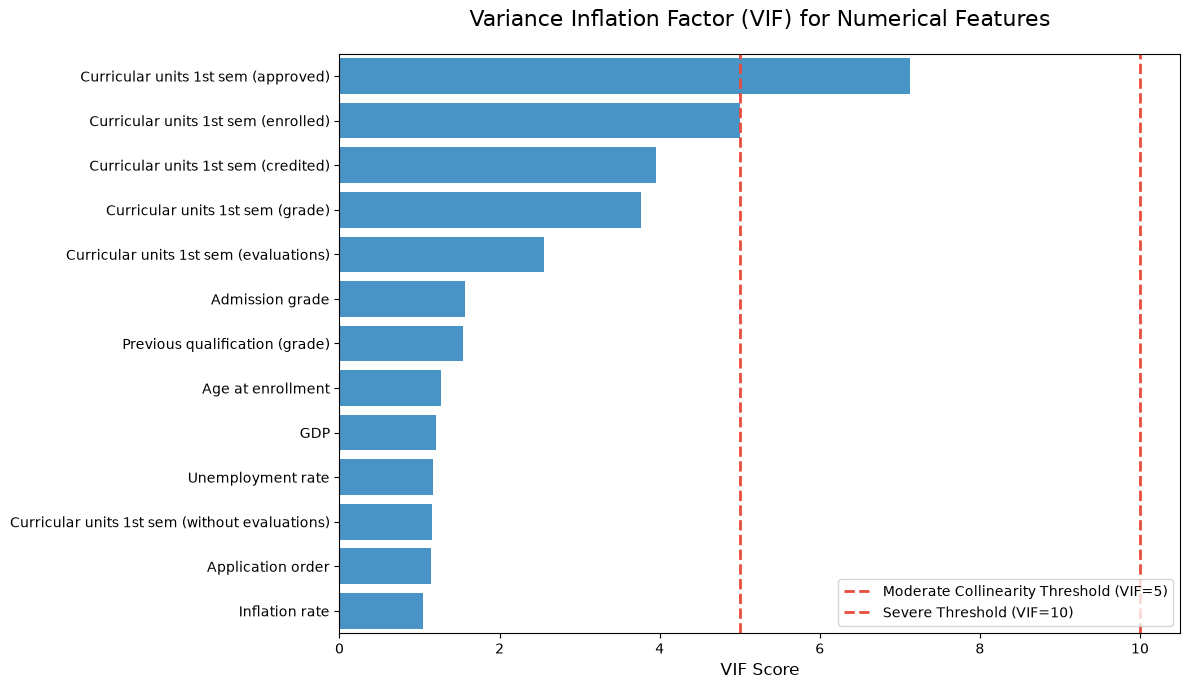

In [45]:
import matplotlib.pyplot as plt 
import seaborn as sns 

# set up figure 
plt.figure(figsize=(12, 7))

# Create a horizontal bar chart
sns.barplot(
    data=vif_data, 
    x="VIF", 
    y="Feature", 
    color="#3498db" 
)
# Add the threshold line
plt.axvline(
    x=5, 
    color='#e74c3c', 
    linestyle='--', 
    linewidth=2, 
    label='Moderate Collinearity Threshold (VIF=5)'
)
plt.axvline(
    x=10,
    color='#e74c3c',
    linestyle='--',
    linewidth=2,
    label='Severe Threshold (VIF=10)'
)

# Apply Titles 
plt.title('Variance Inflation Factor (VIF) for Numerical Features', fontsize=16, pad=20)
plt.xlabel('VIF Score', fontsize=12)
plt.ylabel('') # we hide Y axis label because the features names are self explanatory 
plt.legend(loc='lower right') # Place the legend out of the way

plt.tight_layout()

plt.savefig('../outputs/figures/VIF_Scores_Bar_Chart.png', dpi=300, bbox_inches='tight')

plt.show()

Cramer's V Analysis

In [47]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Define the Cramer's V function
def cramers_v(x, y):
    # Create a confusion matrix of the two categories
    confusion_matrix = pd.crosstab(x, y)
    # Calculate the Chi square statistic 
    chi2 = chi2_contingency(confusion_matrix)[0]
    # Get the total number of observations
    n = confusion_matrix.sum().sum()
    # Get the dimensions of the matrix (rows and columns)
    r, k = confusion_matrix.shape
    # Calculate and retrun the final score of Cramer's V score 
    # we use max(1,..) to prevent vision by zero in perfectly unifrom columns
    return np.sqrt((chi2 / n) / max(1, min(k - 1, r - 1)))

# Define the categorical features 
categorical_cols = [
    'Marital status', 
    'Nacionality', 
    'Mother\'s qualification', 
    'Father\'s qualification', 
    'Mother\'s occupation', 
    'Father\'s occupation', 
    'Application mode', 
    'Course', 
    'Previous qualification'
]
# Isolate the categorical features to prevent mixing with numerical data
X_cat = X[categorical_cols]

# Calculate it for every pair, initialise an empty matrix filled with zero
n_vars = len(categorical_cols)
cramer_matrix = pd.DataFrame(
    np.zeros((n_vars, n_vars)),
    index=categorical_cols,
    columns=categorical_cols
)
# Loop through every possible combination of the features
for col1 in categorical_cols:
    for col2 in categorical_cols:
        cramer_matrix.loc[col1, col2] = cramers_v(X_cat[col1], X_cat[col2])

# unstack the 9x9 grid into a flat table with 3 columns 
cramer_pairs = cramer_matrix.unstack().reset_index()
cramer_pairs.columns = ['Feature 1', 'Feature 2', "Cramer's V"]

# Revome self correlations 
cramer_pairs = cramer_pairs[cramer_pairs['Feature 1'] != cramer_pairs['Feature 2']]

# Drop duplicate pairs
cramer_pairs['pair_key'] = cramer_pairs.apply(
    lambda row: tuple(sorted([row['Feature 1'], row['Feature 2']])), axis=1
)
cramer_pairs = cramer_pairs.drop_duplicates(subset=['pair_key']).drop(columns=['pair_key'])
# Sort from highest overlap to lowest and clean up the row numbers
cramer_pairs = cramer_pairs.sort_values(by="Cramer's V", ascending=False).reset_index(drop=True)

cramer_pairs.head(10)

,Feature 1,Feature 2,Cramer's V
0,Mother's occupation,Father's occupation,0.644843
1,Mother's qualification,Father's qualification,0.444869
2,Application mode,Previous qualification,0.421173
3,Mother's qualification,Mother's occupation,0.265508
4,Mother's qualification,Father's occupation,0.240695
5,Marital status,Application mode,0.234313
6,Nacionality,Application mode,0.233878
7,Father's qualification,Father's occupation,0.207588
8,Father's qualification,Mother's occupation,0.185426
9,Application mode,Course,0.180412


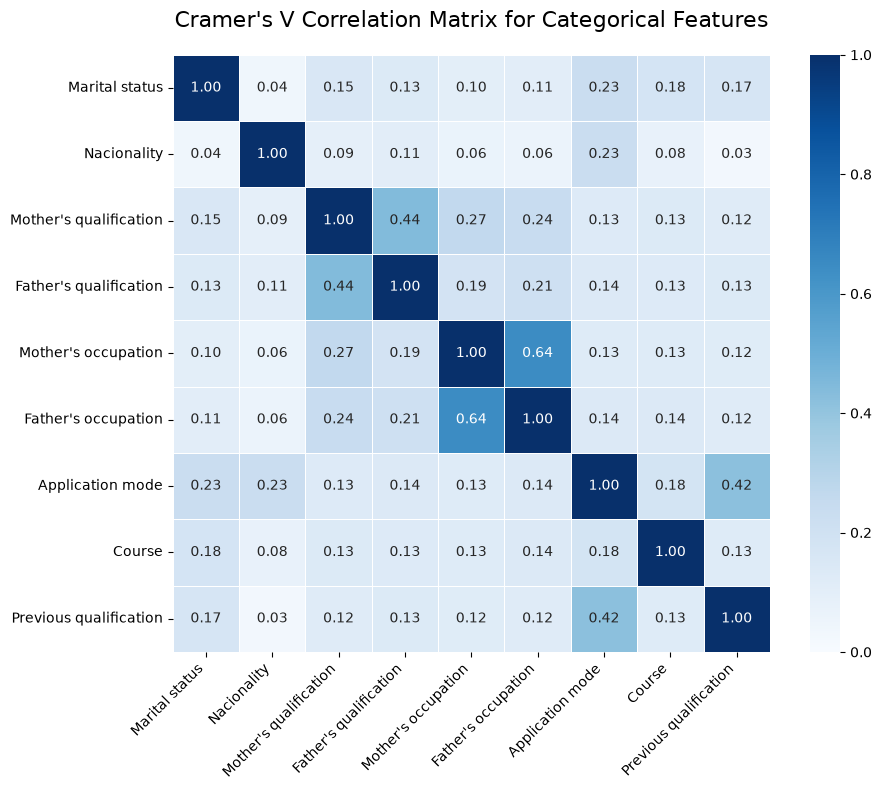

In [52]:
# Display heatmap 
plt.figure(figsize=(10, 8))

# Build the heatmap using the Mako gradient
sns.heatmap(
    cramer_matrix, 
    annot=True,                                   # Show the exact scores in the boxes
    fmt=".2f",                                    # Round to 2 decimal places for a clean look
    cmap="Blues",
    vmin=0, vmax=1,                               # Anchor the scale from 0 to 1
    linewidths=0.5,                               # Add a tiny white border between boxes
    square=True                                   # Force perfect squares
)

# Apply Titles
plt.title("Cramer's V Correlation Matrix for Categorical Features", fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right') # Tilt the bottom labels so they don't overlap
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig('../outputs/figures/Cramers_V_Heatmap.png', dpi=300, bbox_inches='tight')

plt.show()

Train/test split

In [58]:
from sklearn.model_selection import train_test_split

# Split X and y into training and testing sets with specific parameters
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
# Print shapes of all four to confirm 
print(f"Training features (X_train): {X_train.shape}")
print(f"Testing features (X_test): {X_test.shape}")
print(f"Training target (y_train): {y_train.shape}")
print(f"Testing target (y_test): {y_test.shape}")

Training features (X_train): (2904, 30)
Testing features (X_test): (726, 30)
Training target (y_train): (2904,)
Testing target (y_test): (726,)


In [60]:
# Print class distribution in both train and test ti confirm stratification worked 
print("--- Training Set Target Distribution ---")

# normalize=true converts the raw counts into percentages
print(y_train.value_counts(normalize=True).round(3))

print("\n--- Testing Set Target Distribution ---")
print(y_test.value_counts(normalize=True).round(3))

print("\n--- Raw Student Counts ---")

print(f"Training Dropouts (1): {sum(y_train == 1)}")
print(f"Training Graduates (0): {sum(y_train == 0)}")
print(f"Testing Dropouts (1): {sum(y_test == 1)}")
print(f"Testing Graduates (0): {sum(y_test == 0)}")

--- Training Set Target Distribution ---
Target
0    0.608
1    0.392
Name: proportion, dtype: float64

--- Testing Set Target Distribution ---
Target
0    0.609
1    0.391
Name: proportion, dtype: float64

--- Raw Student Counts ---
Training Dropouts (1): 1137
Training Graduates (0): 1767
Testing Dropouts (1): 284
Testing Graduates (0): 442


One hot encoding for Random Forest

In [61]:
import pandas as pd 

# Define the 7 categorical features 
categorical_cols = [
    'Marital status',
    'Nacionality',
    "Mother's occupation",
    "Father's occupation",
    'Application mode',
    'Course',
    'Previous qualification'
]

# Apply One Hot Encoding drop_first= True helps mitigate multicollinearity
X_train_rf = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_rf = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Align the datasets, this will ensure both have exact same columns in the same order
X_train_rf, X_test_rf = X_train_rf.align(X_test_rf, join='left', axis=1, fill_value=0)

print(f"Original features count: {X_train.shape[1]}")
print(f"Random Forest encoded features count: {X_train_rf.shape[1]}")


Original features count: 30
Random Forest encoded features count: 158


In [62]:
# Save the One Hot Encoded training and testing sets
X_train_rf.to_csv('../data/processed/X_train_rf.csv', index=False)
X_test_rf.to_csv('../data/processed/X_test_rf.csv', index=False)

# Save the Target arrays 
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

print("Datasets successfully saved")

Datasets successfully saved


One hot encoding for XGBoost and LightGBM

In [63]:
import pandas as pd 
# Define the 7 categorical features 
categorical_cols = [
    'Marital status',
    'Nacionality',
    "Mother's occupation",
    "Father's occupation",
    'Application mode',
    'Course',
    'Previous qualification'
]

# Create independent copies for the gradient boosting models 
X_train_native = X_train.copy()
X_test_native = X_test.copy()

# Convert the data types to pandas 'category'
for col in categorical_cols:
    X_train_native[col] = X_train_native[col].astype('category')
    X_test_native[col] = X_test_native[col].astype('category')

# Check the transformation
print("--- Data Types ---")
print(X_train_native[categorical_cols].dtypes)



--- Data Types ---
Marital status            category
Nacionality               category
Mother's occupation       category
Father's occupation       category
Application mode          category
Course                    category
Previous qualification    category
dtype: object


In [64]:
# Save as Pickle files to preserve the 'category' metadata
X_train_native.to_pickle('../data/processed/X_train_native.pkl')
X_test_native.to_pickle('../data/processed/X_test_native.pkl')

print("Datasets successfully saved")

Datasets successfully saved


 Compare SMOTE-NC vs Class Weighting

In [68]:
# Define correct categorical indices
categorical_indices = [0, 1, 8, 9, 17, 19, 21]
# Verify indices are correct
print("Categorical columns and their positions:")
for idx in categorical_indices:
    print(f"Position {idx}: {X_train_native.columns[idx]}")

Categorical columns and their positions:
Position 0: Marital status
Position 1: Nacionality
Position 8: Mother's occupation
Position 9: Father's occupation
Position 17: Application mode
Position 19: Course
Position 21: Previous qualification


In [72]:
import numpy as np 
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Define categorical indices 
categorical_indices = [0, 1, 8, 9, 17, 19, 21]

# Define SMOTE NC stratagy 
smote = SMOTENC(categorical_features=categorical_indices, random_state=42)

# Create a pipeline, this enures SMOTE NC is only applied to the traning folds during cross Validation and prevent data leakage
pipeline_smote = Pipeline([
    ('smote', smote),
    ('model', RandomForestClassifier(random_state=42))
])
# Run cross validation 
smote_scores = cross_val_score(
    pipeline_smote,
    X_train_native,
    y_train,
    cv=5,
    scoring='f1'
)
print(f"Mean F1 Score SMOTE-NC: {np.mean(smote_scores):.4f}")

Mean F1 Score SMOTE-NC: 0.8315


In [81]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Create RandomForestClassifier with class weighting
model_weighted = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)
weight_scores = cross_val_score(
    model_weighted,
    X_train_native,
    y_train,
    cv=5,
    scoring='f1'
)
print(f" Mean F1 Score Class Weighting: {np.mean(weight_scores):.4f}")



 Mean F1 Score Class Weighting: 0.8348


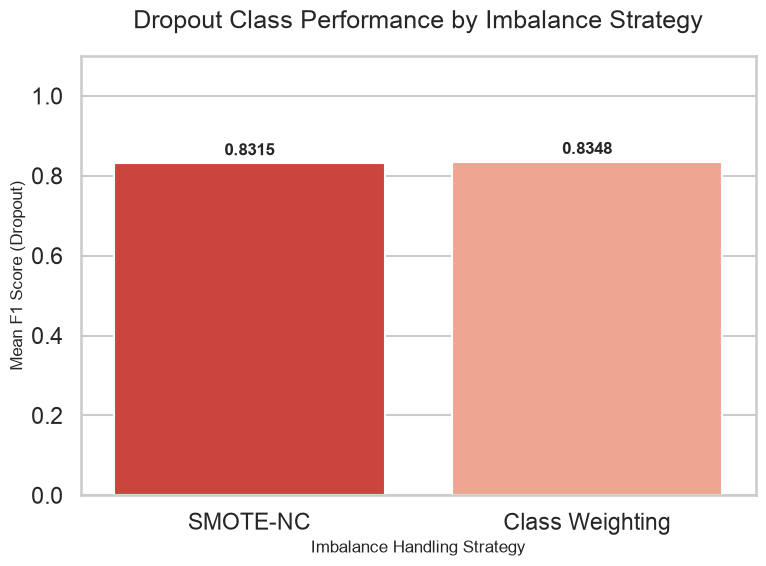

Imbalance strategy comparison generated


In [95]:
import matplotlib.pyplot as plt
import seaborn as sns 
import pandas as pd 

comparison_data = {
    'Strategy': ['SMOTE-NC', 'Class Weighting'],
    'Mean F1 Score': [0.8315, 0.8348]
}
df_imbalance = pd.DataFrame(comparison_data)

# Set up figure
plt.figure(figsize=(8, 6))

# Plot vertical bar chart
ax = sns.barplot(
    x='Strategy',   
    y='Mean F1 Score',  
    hue='Strategy',
    data=df_imbalance,
    legend=False,
    palette='Reds_r'
)
# Add exact performance labels on top of the bars
for i, row in df_imbalance.iterrows():
    val = row['Mean F1 Score']
    label = f'{val:.4f}'

    # Place text safely above the top of the bar using a minor decimal buffer
    plt.text(i, val + 0.02, label, ha='center', fontsize=12, fontweight='bold')

# Apply Titles
plt.title('Dropout Class Performance by Imbalance Strategy', fontsize=18, pad=20)
plt.ylabel('Mean F1 Score (Dropout)', fontsize=12)
plt.xlabel('Imbalance Handling Strategy', fontsize=12)

plt.ylim(0, 1.1)
plt.tight_layout()

plt.savefig('../outputs/figures/Imbalance_Strategy_Comparison.png', dpi=300, bbox_inches='tight')

plt.show()

print("Imbalance strategy comparison generated")